<a href="https://colab.research.google.com/github/cmburban/MAT-422/blob/main/MAT422_Section_2_4_MLE_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 2.4: MLE and Linear Regression

**Topics:** MLE for random samples, Linear regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(422)

## 2.4.1 MLE for Random Samples

Maximum likelihood estimation (MLE) is a method for estimating an unknown parameter using observed data. The idea is to choose the parameter value that makes the observed sample most likely.

I will use a sample of coin flips to estimate the probability of getting heads. The MLE for the probability of heads is the proportion of heads observed in the sample.

In [2]:
# A sample of 20 coin flips
sample = np.array([
    1, 0, 1, 1, 0,
    1, 0, 1, 1, 1,
    0, 1, 1, 0, 1,
    1, 0, 1, 1, 0
])

n = len(sample)
successes = sample.sum()

# Maximum likelihood estimate for the probability of heads
p_hat = successes / n

print("Number of coin flips:", n)
print("Number of heads:", successes)
print("MLE for probability of heads:", p_hat)

Number of coin flips: 20
Number of heads: 13
MLE for probability of heads: 0.65


The MLE for the probability of heads is 0.65. This means that based on the sample, the estimated probability of getting heads is 65%. The estimate comes directly from the proportion of heads in the observed sample.

### Visualizing the Likelihood

The likelihood tells us how well different values of p explain the observed sample. The MLE should occur at the value of p where the likelihood is largest.

MLE from the likelihood curve: 0.6502010050251257
MLE from the sample proportion: 0.65


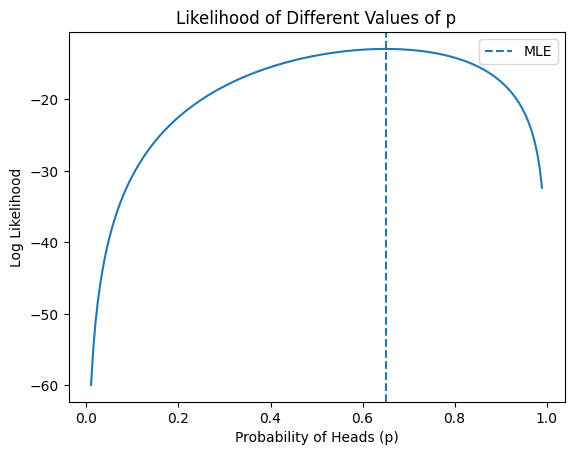

In [3]:
p_values = np.linspace(0.01, 0.99, 200)

log_likelihood = (
    successes * np.log(p_values)
    + (n - successes) * np.log(1 - p_values)
)

best_p = p_values[np.argmax(log_likelihood)]

print("MLE from the likelihood curve:", best_p)
print("MLE from the sample proportion:", p_hat)

plt.plot(p_values, log_likelihood)
plt.axvline(p_hat, linestyle="--", label="MLE")

plt.xlabel("Probability of Heads (p)")
plt.ylabel("Log Likelihood")
plt.title("Likelihood of Different Values of p")
plt.legend()

plt.show()

The likelihood curve reaches its highest point near the estimated value of 0.65. This agrees with the MLE calculated from the sample proportion. The graph shows that p = 0.65 provides the best explanation of the observed coin-flip data among the values tested.

## 2.4.2 Linear Regression

Linear regression models the relationship between a dependent variable and one or more independent variables. In simple linear regression, the model has the form

\[
y = $ \beta_{0} $ + $ \beta_{1} $x
\]

where $\beta_0$ is the intercept and $\beta_1$ is the slope.

I will use study hours and test scores as an example. The goal is to find the line that best describes the relationship between the two variables.

In [4]:
# Study hours and test scores
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([62, 67, 71, 78, 84, 89])

# Add a column of ones for the intercept
X = np.column_stack((np.ones(len(x)), x))

# Calculate the regression coefficients
beta = np.linalg.lstsq(X, y, rcond=None)[0]

intercept = beta[0]
slope = beta[1]

print("Intercept:", intercept)
print("Slope:", slope)

# Predicted values
y_pred = X @ beta

print("\nPredicted scores:")
print(y_pred)

Intercept: 55.86666666666669
Slope: 5.514285714285719

Predicted scores:
[61.381  66.8952 72.4095 77.9238 83.4381 88.9524]


The slope shows how much the predicted test score changes for each additional hour of studying. The intercept represents the predicted score when the number of study hours is zero. The predicted values give the scores estimated by the regression line.

### Checking the Regression Model

I can compare the predicted scores with the actual scores to see how closely the regression line fits the data. The residual is the difference between an observed value and its predicted value.

In [5]:
residuals = y - y_pred

mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print("Residuals:")
print(residuals)

print("\nMean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Residuals:
[ 0.619   0.1048 -1.4095  0.0762  0.5619  0.0476]

Mean Squared Error: 0.450793650793651
Root Mean Squared Error: 0.6714116850291265


The residuals show the differences between the actual and predicted test scores. The RMSE gives the typical size of the prediction error in the same units as the test scores. A smaller RMSE indicates that the regression line is closer to the observed data.

### Visualizing the Regression Line

A scatter plot shows the original data points, while the regression line shows the model's predicted relationship between study hours and test scores.

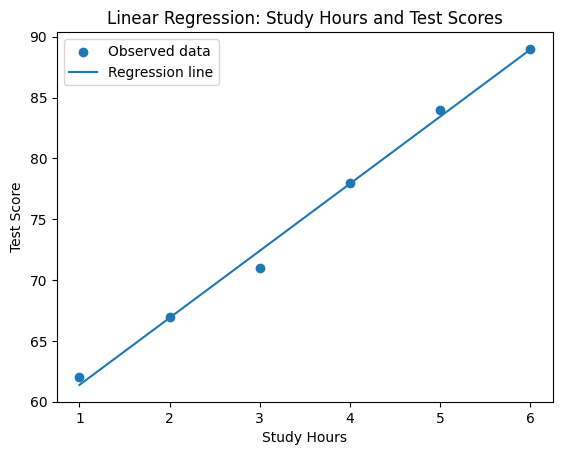

In [6]:
plt.scatter(x, y, label="Observed data")
plt.plot(x, y_pred, label="Regression line")

plt.xlabel("Study Hours")
plt.ylabel("Test Score")
plt.title("Linear Regression: Study Hours and Test Scores")
plt.legend()

plt.show()

The scatter plot shows a positive relationship between study hours and test scores. The regression line follows the overall pattern of the data and provides a simple way to predict test scores from study hours. The residual and RMSE calculations provide a numerical check of how well the line fits the observed data.

## End of Notebook Reflection

In this notebook, I learned how maximum likelihood estimation can be used to estimate an unknown parameter from a sample of data. In the coin-flip example, the MLE was based on the proportion of heads in the sample. The likelihood curve also showed that the estimated value was the point where the observed data was most likely. I also learned how linear regression can be used to describe the relationship between two variables. In my example, I used study hours and test scores to create a regression line. The slope showed how the predicted test score changed as study hours increased. I also used residuals and RMSE to check how closely the regression line fit the observed data. Overall, these examples helped me understand how MLE can be used to estimate parameters from data and how linear regression can be used to describe relationships and make predictions.

## References

[Mathematical Methods in Data Science - Elsevier (2023)](https://doi.org/10.1016/B978-0-44-318679-0.00007-7)

[Numpy - Singular Value Decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)

[Matplotlib](https://matplotlib.org/stable/)

[OpenAI - ChatGPT (2026)](https://chatgpt.com)

## Submission Checklist

- I explained each concept in words before or after the code. [DONE]
- I verified important claims numerically or visually. [DONE]
- I changed or extended at least one example so the notebook reflects my own work. [DONE]
- I ran the notebook from top to bottom without errors. [DONE]
- I saved the notebook from Google Colab directly to GitHub, following the course instructions. [DONE]